# Análisis Dataset

In [76]:
import pandas as pd
from datasets import load_dataset
dataset = load_dataset("opus100", "en-es")

data = pd.DataFrame(dataset['train']['translation'])
data.head(10)

,en,es
0,"It was the asbestos in here, that's what did it!",Fueron los asbestos aquí. ¡Eso es lo que ocurrió!
1,I'm out of here.,Me voy de aquí.
2,"One time, I swear I pooped out a stick of chalk.","Una vez, juro que cagué una barra de tiza."
3,"And I will move, do you understand me?","Y prefiero mudarme, ¿Entiendes?"
4,"- Thank you, my lord.",- Gracias.
5,You have to help me.,Debes ayudarme.
6,Fuck this!,¡Por la mierda!
7,The safety and efficacy of MIRCERA therapy in ...,No se ha establecido la seguridad y eficacia d...
8,You can stay if you want.,"Así lo decidí, pueden quedarse si quieren."
9,"Of course, when I say 'translating an idiom,' ...","Por supuesto, cuando digo 'traducir un idioma'..."


In [77]:
# Así medimos la longitud de la partición completa, sin entrar a la columna
print(f"Tamaño dataset inicial Train: {len(dataset['train'])}")
print(f"Tamaño dataset inicial Test: {len(dataset['test'])}")
print(f"Tamaño dataset inicial Validation: {len(dataset['validation'])}")

Tamaño dataset inicial Train: 1000000
Tamaño dataset inicial Test: 2000
Tamaño dataset inicial Validation: 2000


In [78]:
#Nulos, vacíos, idénticos y longitud mínima

data_clean = data.dropna().copy()
data_clean = data_clean[(data_clean['en'].str.strip() != "") & (data_clean['es'].str.strip() != "")] #vacios
data_clean = data_clean[data_clean['en'].str.lower().str.strip() != data_clean['es'].str.lower().str.strip()] #eliminamos identicos
data_clean = data_clean[(data_clean['en'].str.split().str.len() >= 3) & (data_clean['es'].str.split().str.len() >= 3)]
data_clean = data_clean.drop_duplicates(subset=['en','es'])

long_en = data_clean['en'].str.split().str.len()
long_es = data_clean['es'].str.split().str.len()
ratio = long_es / long_en

#Filtrado final por ratio (0.5 < ratio < 2.0)
mask = (ratio > 0.5) & (ratio < 2.0) 
data_clean = data_clean[(ratio > 0.5) & (ratio < 2.0)]


metrics = pd.DataFrame({
    'long_en': long_en[mask],
    'long_es': long_es[mask],
    'ratio': ratio[mask]
})

print(f"Pares de frases eliminados: {len(data) - len(data_clean)}")

Pares de frases eliminados: 240144


In [79]:
percentiles = [.25, .5, .75, .9, .95]
datos = metrics[[ 'long_en', 'long_es','ratio']].describe(percentiles=percentiles)

pd.options.display.float_format = '{:.2f}'.format
datos

,long_en,long_es,ratio
count,759856.00,759856.00,759856.00
mean,12.94,13.46,1.02
std,13.21,14.84,0.24
min,3.00,3.00,0.50
25%,5.00,5.00,0.83
50%,8.00,8.00,1.00
75%,16.00,16.00,1.17
90%,28.00,31.00,1.33
95%,38.00,43.00,1.45
max,1737.00,1721.00,1.98


Observamos que, a pesar de que el 95% de las frases tengan una longitud menor o igual a 38 en ingles, la lonngitud maxima es de 1737 por lo que aun asi decidimos filtrar más las traducciones en base 
a esta observacion:

In [80]:
long_en = data_clean['en'].str.split().str.len()
long_es = data_clean['es'].str.split().str.len()

data_clean = data_clean[(long_en <= 64) & (long_es <= 64)]

print(f"Tamaño final del dataset: {len(data_clean)}")

Tamaño final del dataset: 749103


In [19]:
def lexico(df):

    #aplica a cada frase una separacion por caracteres sin tener en cuenta signos de puntuacion, interrogacion y exclamacion
    #\w+ es una ER
    vocab = df.str.lower().str.findall(r'\w+') ##tipo panda.Series()
    vocab = vocab.explode() #convierte cada elemento en una fila pero no tiene en cuenta repetidos
    vocab = vocab.value_counts()
    
    return vocab.to_dict()


en_vocab = lexico(data_clean['en'])
es_vocab = lexico(data_clean['es'])

vocab = pd.DataFrame()
vocab['Palabras Unicas Ingles'] = [len(en_vocab)]
vocab['Palabras Unicas Español'] = [len(es_vocab)]
vocab
    

,Palabras Unicas Ingles,Palabras Unicas Español
0,152068,208369


In [20]:
from collections import Counter
import re

n = 10

top_en = Counter(en_vocab).most_common(n)
top_es = Counter(es_vocab).most_common(n)
    
# Creamos el DataFrame
tabla = pd.DataFrame({
    'Rank': range(1, n + 1),
    'Word (EN)': [word for word, count in top_en],
    'Freq (EN)': [f"{count:,}" for word, count in top_en],
    'Word (ES)': [word for word, count in top_es],
    'Freq (ES)': [f"{count:,}" for word, count in top_es]
    })

tabla

,Rank,Word (EN),Freq (EN),Word (ES),Freq (ES)
0,1,the,"532,625",de,"582,017"
1,2,of,"268,586",la,"331,605"
2,3,to,"249,572",que,"266,058"
3,4,and,"222,554",el,"237,683"
4,5,you,"182,139",en,"230,591"
5,6,i,"179,156",y,"218,430"
6,7,a,"174,868",a,"205,047"
7,8,in,"165,885",los,"142,553"
8,9,that,"114,410",no,"140,768"
9,10,it,"104,917",un,"101,677"


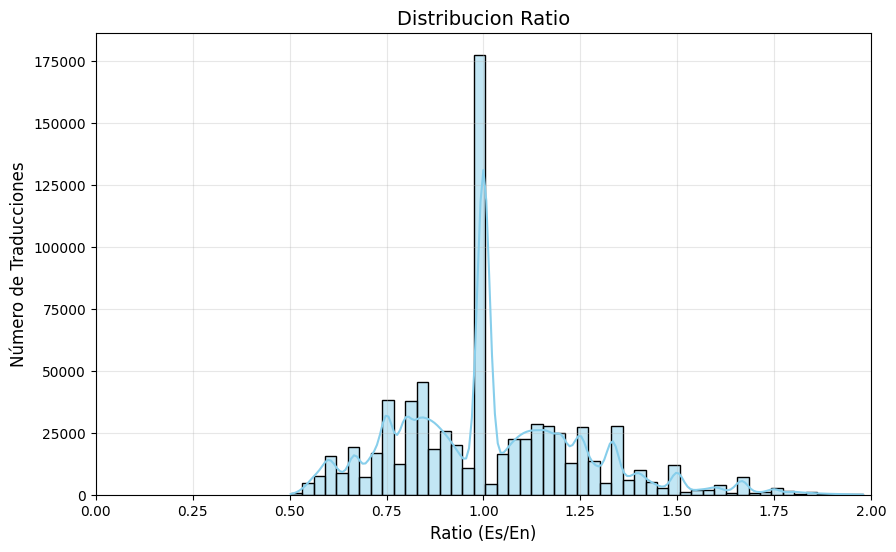

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def histograma(df,title,x_label,y_label,x_min,x_max,save_fig="histograma",bins = 50,color = 'skyblue'):
    plt.figure(figsize=(10, 6))
    
    # Creamos el histograma con una línea de densidad (KDE)
    sns.histplot(df, bins=bins, kde=True, color=color)
    
   
    # Configuración de estética
    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.xlim(x_min, x_max) # Limitamos la vista para que se vea bien el grueso de los datos
    plt.grid(alpha=0.3)
    
    plt.savefig(save_fig)
    plt.show()


# Para ejecutarlo:
histograma(metrics['ratio'],title="Distribucion Ratio",x_label="Ratio (Es/En)",y_label="Número de Traducciones",x_min = 0,x_max=2)

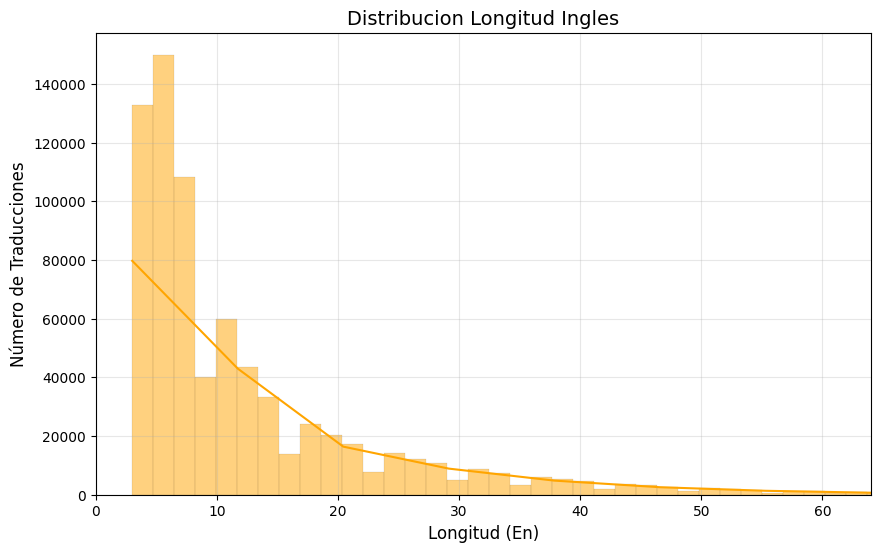

In [34]:
histograma(metrics['long_en'],title="Distribucion Longitud Ingles",x_label="Longitud (En)",y_label="Número de Traducciones",x_min=0,x_max=64,bins = 1000,color="orange")

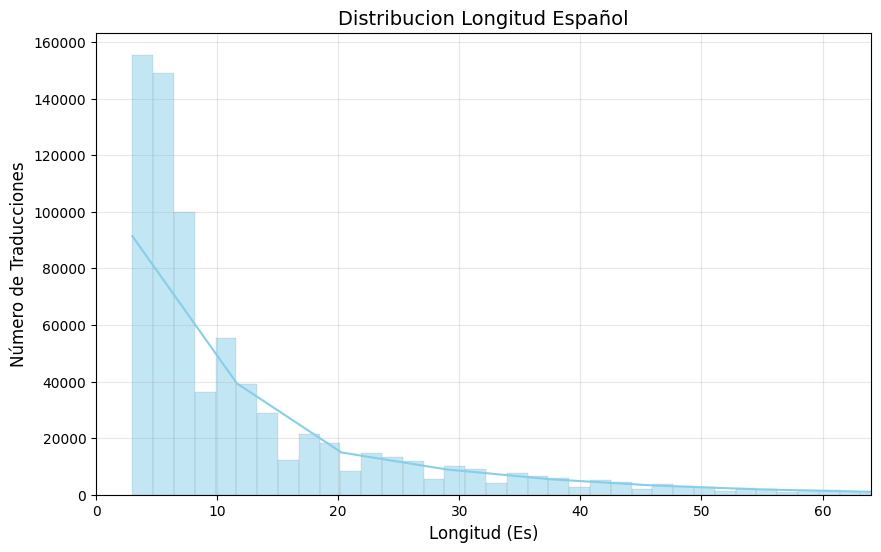

In [35]:
histograma(metrics['long_es'],title="Distribucion Longitud Español",x_label="Longitud (Es)",y_label="Número de Traducciones",x_min=0,x_max=64,bins = 1000,color="skyblue")

# Vocabulario y Tokenizador

In [ ]:
#Volvemos a cargar el dataset y creamos una funcion que filtrará en base al analisis previo
from datasets import load_dataset
dataset = load_dataset("opus100", "en-es")

seen = set()

def is_valid(example):
    pair = example['translation']

    if pair in seen(): return False
        
    en = pair['en']
    es = pair['es']

    print(en)
    print(es)
    if en.strip() == "" or es.strip() == "": return False #Alguno vacio
    if en.lower().strip() == es.lower().strip(): return False #PAr exactamente igual

    if len(en.split()) < 3 or len(es.split()) < 3: return False
    if len(en.split()) > 64 or len(es.split()) > 64 : return False
    ratio = len(es.split()) / len(en.split())
    if ratio <= 0.5 or ratio >= 2:          return False
    

    seen.add(pair)
    return True

dataset['train'] = dataset['train'].filter(is_valid,num_proc=1)



In [90]:
dataset['train']['translation'][0]

{'en': "It was the asbestos in here, that's what did it!",
 'es': 'Fueron los asbestos aquí. ¡Eso es lo que ocurrió!'}

In [ ]:
data_clean = data.dropna().copy()
data_clean = data_clean[(data_clean['en'].str.strip() != "") & (data_clean['es'].str.strip() != "")] #vacios
data_clean = data_clean[data_clean['en'].str.lower().str.strip() != data_clean['es'].str.lower().str.strip()] #eliminamos identicos
data_clean = data_clean[(data_clean['en'].str.split().str.len() >= 3) & (data_clean['es'].str.split().str.len() >= 3)]
data_clean = data_clean.drop_duplicates(subset=['en','es'])

long_en = data_clean['en'].str.split().str.len()
long_es = data_clean['es'].str.split().str.len()
ratio = long_es / long_en

In [63]:
print(len(dataset['train']))

764119


In [55]:
import json
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

tokenizer = Tokenizer(BPE(unk_token="<UNK>"))

#ByteLevel para no perder los espacios
tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
tokenizer.decoder = ByteLevelDecoder()

entrenador = BpeTrainer(
    vocab_size=16000, 
    special_tokens=["<PAD>", "<START>", "<END>", "<UNK>"],
    initial_alphabet=ByteLevel.alphabet() #
)

def iterator(data):
    for translation in data:
        en = translation['en']
        es = translation['es']
        print(en)
        print(es)

        yield en
        yield es

tokenizer.train_from_iterator(iterator(dataset['train']['translation']), trainer=entrenador)
tokenizer.save("vocab_16k.json")